# FractalDSL — Notebook de Exemplos

Este notebook demonstra a **FractalDSL**, uma linguagem de domínio específico embutida em **Guile/Scheme** para descrever e renderizar fractais declarativamente.

## Pipeline de execução

```
arquivo .frac
     │
     ▼  fractal-reader.scm (parser de indentação + eval Scheme)
fractal alist  ──────────────────────────────────────────────────
     │                                                           │
     ▼  generate()                                              │
  modo coastline     →  deslocamento de ponto médio + IFS       │
  modo equation      →  grid de escape-time (Mandelbrot/Julia)  │
  modo IFS           →  jogo do caos (chaos game)               │
     │                                                           │
     ▼  export-csv()                                            │
  pontos.csv  (x, y, type, value)                               │
     │                                                           │
     ▼  render_fractal.py  ◄──────────────────────────────────── │
  imagem.png
```

A DSL cuida da **matemática e estrutura**. O Python cuida dos **pixels**.
Desde a versão 3-final, o comando `generate` em um arquivo `.frac` aciona automaticamente o renderer Python se houver um bloco `render`.

In [1]:
import subprocess, os, sys
from pathlib import Path
from IPython.display import Image, display, Markdown

# Diretório base do projeto
BASE = Path(os.getcwd())
GUILE_DIR = BASE / 'guile'
FRAC_DIR  = BASE
PYTHON_RENDERER = BASE / 'python' / 'render_fractal.py'

def guile_available():
    try:
        r = subprocess.run(['guile', '--version'], capture_output=True, timeout=5)
        return r.returncode == 0
    except FileNotFoundError:
        return False

HAS_GUILE = guile_available()
print(f'Guile disponível: {HAS_GUILE}')
print(f'Base: {BASE}')

def run_frac(frac_file, timeout=120):
    """Executa um .frac via Guile. Retorna (stdout, stderr, returncode)."""
    if not HAS_GUILE:
        return '', 'Guile não instalado — usando CSV/PNG pré-gerados.', 1
    abs_frac = (FRAC_DIR / frac_file).resolve()
    result = subprocess.run(
        ['guile', '--no-auto-compile', '-c',
         f'(load "fractal-reader.scm") (run-frac-file "{abs_frac}")'],
        capture_output=True, text=True,
        cwd=str(GUILE_DIR), timeout=timeout
    )
    return result.stdout, result.stderr, result.returncode

def render_csv(csv_name, png_name, style='island', color=None, width=900, height=900):
    """Chama render_fractal.py diretamente sobre um CSV existente."""
    csv_path = GUILE_DIR / csv_name
    png_path = GUILE_DIR / png_name
    cmd = ['python3', str(PYTHON_RENDERER), str(csv_path), str(png_path),
           '--style', style, '--width', str(width), '--height', str(height)]
    if color:
        cmd += ['--color', color]
    subprocess.run(cmd, capture_output=True)
    return png_path

def show_frac(frac_file):
    """Mostra o conteúdo de um .frac file."""
    content = (FRAC_DIR / frac_file).read_text()
    display(Markdown(f'```\n{content}\n```'))

def show_png(png_name, width=600):
    png_path = GUILE_DIR / png_name
    if png_path.exists():
        display(Image(str(png_path), width=width))
    else:
        print(f'PNG não encontrado: {png_path}')

Guile disponível: True
Base: /Users/ygor.jesus/Documents/Personal/UNICAMP/ParadigmasProg/projeto-estudos-mc346/project-3-final


---
## Definições da DSL — sintaxe e lógica principal de cada arquivo

Antes dos exemplos, um resumo do que cada arquivo faz e das primitivas que ele expõe — a mesma ordem em que um arquivo `.frac` é processado: o **reader** parseia texto → gera chamadas para as primitivas do **backend** → o backend devolve pontos → o **generate** exporta CSV → o **renderer Python** desenha o PNG.

### `fractal-core.scm` — estrutura de dados + aritmética complexa

Todo fractal é uma **association list (alist)** imutável. `set-field` nunca muta — devolve uma alist nova com o campo trocado.

```scheme
(create-fractal name)      ; => alist com name/equation/ifs/coastline/
                            ;    constants/iterations/center/zoom/resolution
(set-field fractal field value)   ; devolve NOVA alist (sem mutação)
(get-field fractal field)         ; lê um campo (#nil se ausente)

; complexos representados como (cons real imag)
(make-c r i) (c-real z) (c-imag z)
(c+ a b) (c- a b) (c* a b) (c-abs z) (c-pow z n)
```

### `fractal-params.scm` — primitivas de parâmetro

Cada primitiva recebe um fractal e devolve outro — é isso que permite encadear chamadas em pipeline funcional (`(zoom (center (iterations f 150) -0.5 0) 100)`).

```scheme
(equation fractal expr-str)     ; ex.: "z=z^2+c"
(constant fractal name value)   ; parâmetro extra (ex.: c do Julia)
(iterations fractal n)
(center fractal re im)
(zoom fractal z)
(resolution fractal w h)
(color fractal scheme)
```

### `fractal-ifs.scm` — Sistemas de Funções Iteradas

`affine`/`transform` descrevem uma transformação afim com peso; `ifs` anexa uma lista de `transform` ao fractal; `with-depth` marca um sub-fractal para ser expandido por `d` níveis antes de devolver um ponto ao fractal que o contém — é isso que permite um fractal ser **valor de primeira classe** dentro de outro.

```scheme
(affine a b c d e f)          ; => (affine a b c d e f)
(transform prob aff)          ; => (transform prob aff)
(ifs fractal . transforms)    ; anexa transforms ao campo 'ifs
(with-depth d fractal)        ; marca profundidade de expansão

; execução: jogo do caos com pilha explícita (evita recursão infinita)
(iterate-ifs fractal n)       ; => lista de pontos (x y)
```

### `fractal-coastline.scm` — costa por deslocamento de ponto médio

Gera um polígono inicial (N vértices, `radius`), subdivide cada aresta recursivamente (`depth` níveis) deslocando o ponto médio por um valor aleatório proporcional a `roughness`. `decorate-coastline` estampa uma nuvem de pontos IFS (ex.: Barnsley Fern) em cada aresta; `decorate-interior` estampa nuvens também no *miolo* do polígono (uma por fatia angular), pra preencher o interior, não só a borda.

```scheme
(generate-coastline points radius roughness depth)  ; => lista de (x y)
(decorate-coastline polygon transforms steps scale)  ; nuvem na borda
(decorate-interior polygon transforms steps scale n radius-fraction)
(generate-island params)   ; junta coastline + decorate (borda + miolo)
```

### `fractal-generate.scm` — parser de equação + `generate` + `export-csv`

`parse-equation` reconhece as formas suportadas (`z^n+c`, `z^n-c`, `z^n`, `z*z+c`) e devolve uma função `(z c) -> z'`. `generate` olha os campos do fractal (`coastline`, `ifs`, `equation`, nessa ordem de prioridade) e escolhe o motor de geração certo. `export-csv` roda `generate` e escreve `x,y,type,value` — `type` é `coast`/`decor` (costa), `escape` (Mandelbrot/Julia) ou `point` (IFS puro).

```scheme
(parse-equation str)                 ; => (lambda (z c) z')
(iterate-equation f max-iter c)      ; escape-time de um único ponto
(generate-equation-grid fractal)     ; escaneia o plano, 1 pixel por c
(generate fractal)                   ; despacha coastline/ifs/equation
(export-csv fractal filename)        ; roda generate + escreve o CSV
```

### `fractal-reader.scm` — parser do `.frac`

Lê o arquivo linha a linha, mede indentação (`indent-of`) e monta uma árvore lógica a partir da contagem de espaços (`to-indexed` + `direct-children`). Cada bloco de nível 0 (`define`, `fractal`, `render`, `generate`) é compilado para uma expressão Scheme e avaliada com `eval`. Também resolve a camada de composição do próprio `.frac`:

```
define decoration <Nome>   ; registra decoração nomeada (reutilizável)
    ...

define style <Nome>        ; registra geometria nomeada (reutilizável)
    ...

fractal <Nome>
    coastline
        extends <Style>     ; herda geometria, campo a campo
        decorate
            use <Decoração> ; pode repetir — soma/compõe as decorações
            use <Outra>
```

Nomes duplicados (`define decoration`, `define style` ou `fractal` repetidos) dão erro na hora do parse, não silenciosamente sobrescrevem.

---
## Exemplo 1 — Ilha (`ilha.frac`)

**Modo:** coastline + decoração IFS  
**Técnica:** polígono de 7 vértices subdividido 6 vezes (midpoint displacement), decorado com Barnsley Fern em cada aresta.

In [2]:
show_frac('ilha.frac')

```
fractal Ilha
    iterations 10000
    coastline
        points 7
        radius 1.0
        roughness 0.4
        depth 6
        decorate
            steps 80
            scale 0.06
            transform 0.85
                depth 4
                barnsley
                    affine 0.85  0.85  0.04 -0.04  0.85  0.0  1.60
            transform 0.07
                depth 4
                barnsley
                    affine 0.07  0.20 -0.26  0.23  0.22  0.0  1.60
            transform 0.07
                depth 4
                barnsley
                    affine 0.07 -0.15  0.28  0.26  0.24  0.0  0.44
            transform 0.01
                depth 4
                barnsley
                    affine 0.01  0.0   0.0   0.0   0.16  0.0  0.0

render
    resolution 1200 1200
    color mono
    style island

generate Ilha

```

  36,208 pontos carregados de ilha.csv
    coast: 448 pts  |  decor: 35,760 pts
  → salvo em ilha.png
Compilando: Ilha
(define Ilha (let* ((f (create-fractal Ilha)) (f (set-field f (quote iterations) 10000)) (f (set-field f (quote coastline) (list (cons (quote points) 7) (cons (quote radius) 1.0) (cons (quote roughness) 0.4) (cons (quote depth) 6) (cons (quote decorate) (list (cons (quote steps) 80) (cons (quote scale) 0.06) (cons (quote transforms) (list (transform 0.85 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.85 (affine 0.85 0.04 -0.04 0.85 0.0 1.6))))) (transform 0.07 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.07 (affine 0.2 -0.26 0.23 0.22 0.0 1.6))))) (transform 0.07 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.07 (affine -0.15 0.28 0.26 0.24 0.0 0.44))))) (transform 0.01 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.01 (affine 0.0 0.0 0.0 0.16 0.0 0.0))))))))))))) f))
Configurando render: ((width . 1200) (he

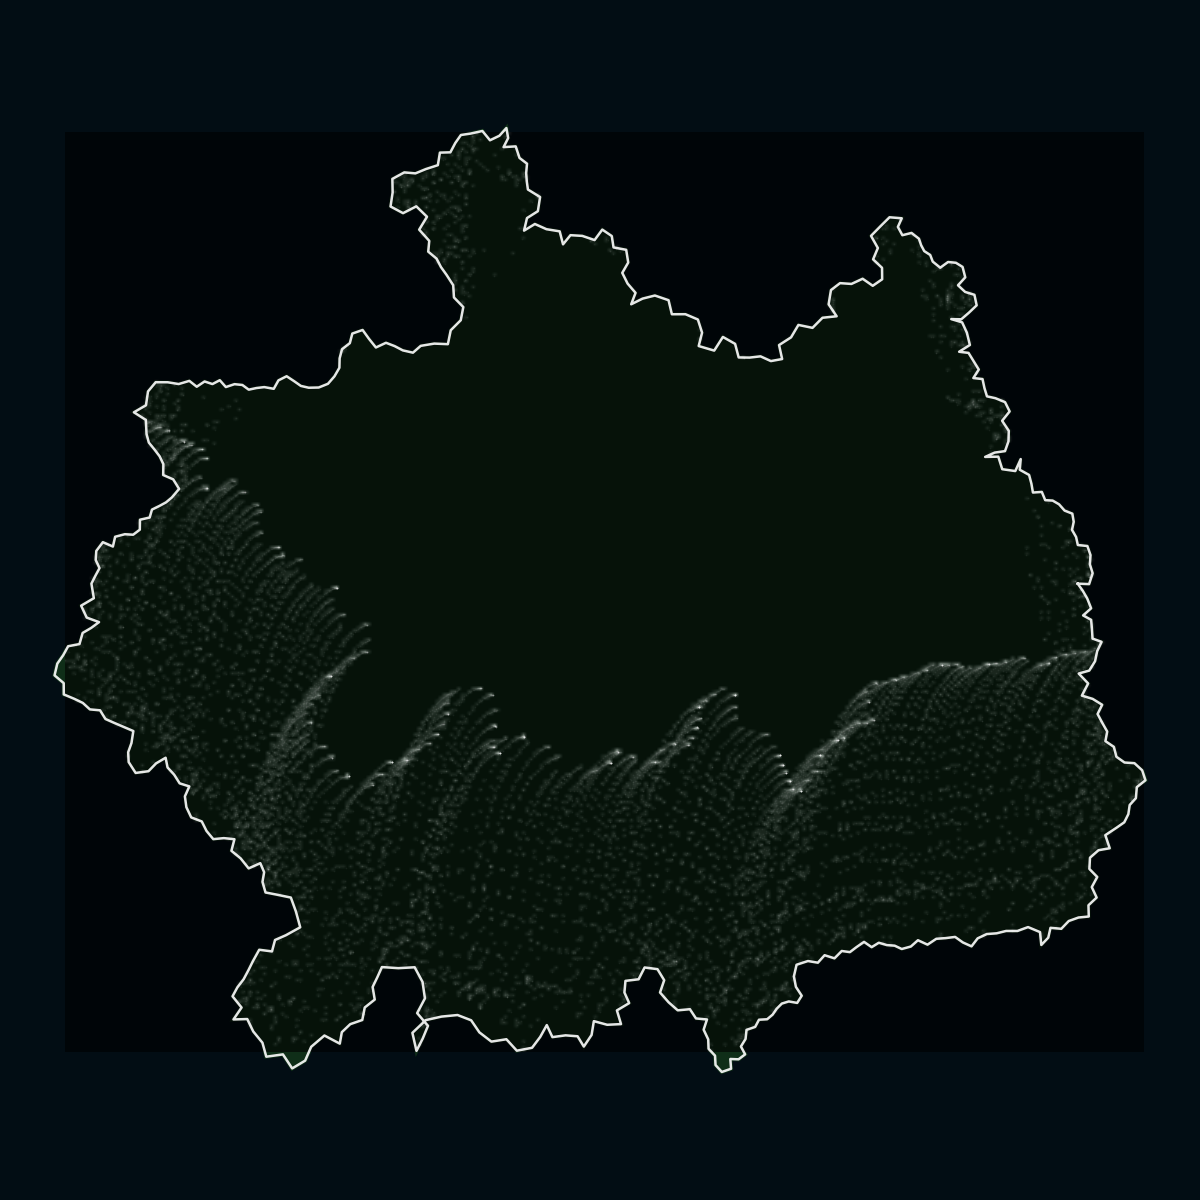

In [3]:
stdout, stderr, rc = run_frac('ilha.frac')
if rc == 0:
    print(stdout)
else:
    print(stderr or '(usando PNG pré-gerado)')
    render_csv('ilha.csv', 'ilha.png', style='island', color='mono')

show_png('ilha.png')

---
## Exemplo 2 — Floresta (`floresta.frac`)

**Modo:** coastline + decoração IFS  
**Diferença:** 9 pontos, `roughness 0.55` (costa mais recortada), `steps 120` (vegetação mais densa). Estilo `forest`: interior verde escuro, sem outline duro.

In [4]:
show_frac('floresta.frac')

```
fractal Floresta
    iterations 10000
    coastline
        points 9
        radius 1.0
        roughness 0.55
        depth 5
        decorate
            steps 120
            scale 0.09
            transform 0.85
                depth 4
                barnsley
                    affine 0.85  0.85  0.04 -0.04  0.85  0.0  1.60
            transform 0.07
                depth 4
                barnsley
                    affine 0.07  0.20 -0.26  0.23  0.22  0.0  1.60
            transform 0.07
                depth 4
                barnsley
                    affine 0.07 -0.15  0.28  0.26  0.24  0.0  0.44
            transform 0.01
                depth 4
                barnsley
                    affine 0.01  0.0   0.0   0.0   0.16  0.0  0.0

render
    resolution 1200 1200
    style forest

generate Floresta

```

  34,728 pontos carregados de floresta.csv
    coast: 288 pts  |  decor: 34,440 pts
  → salvo em floresta.png
Compilando: Floresta
(define Floresta (let* ((f (create-fractal Floresta)) (f (set-field f (quote iterations) 10000)) (f (set-field f (quote coastline) (list (cons (quote points) 9) (cons (quote radius) 1.0) (cons (quote roughness) 0.55) (cons (quote depth) 5) (cons (quote decorate) (list (cons (quote steps) 120) (cons (quote scale) 0.09) (cons (quote transforms) (list (transform 0.85 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.85 (affine 0.85 0.04 -0.04 0.85 0.0 1.6))))) (transform 0.07 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.07 (affine 0.2 -0.26 0.23 0.22 0.0 1.6))))) (transform 0.07 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.07 (affine -0.15 0.28 0.26 0.24 0.0 0.44))))) (transform 0.01 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.01 (affine 0.0 0.0 0.0 0.16 0.0 0.0))))))))))))) f))
Configurando rende

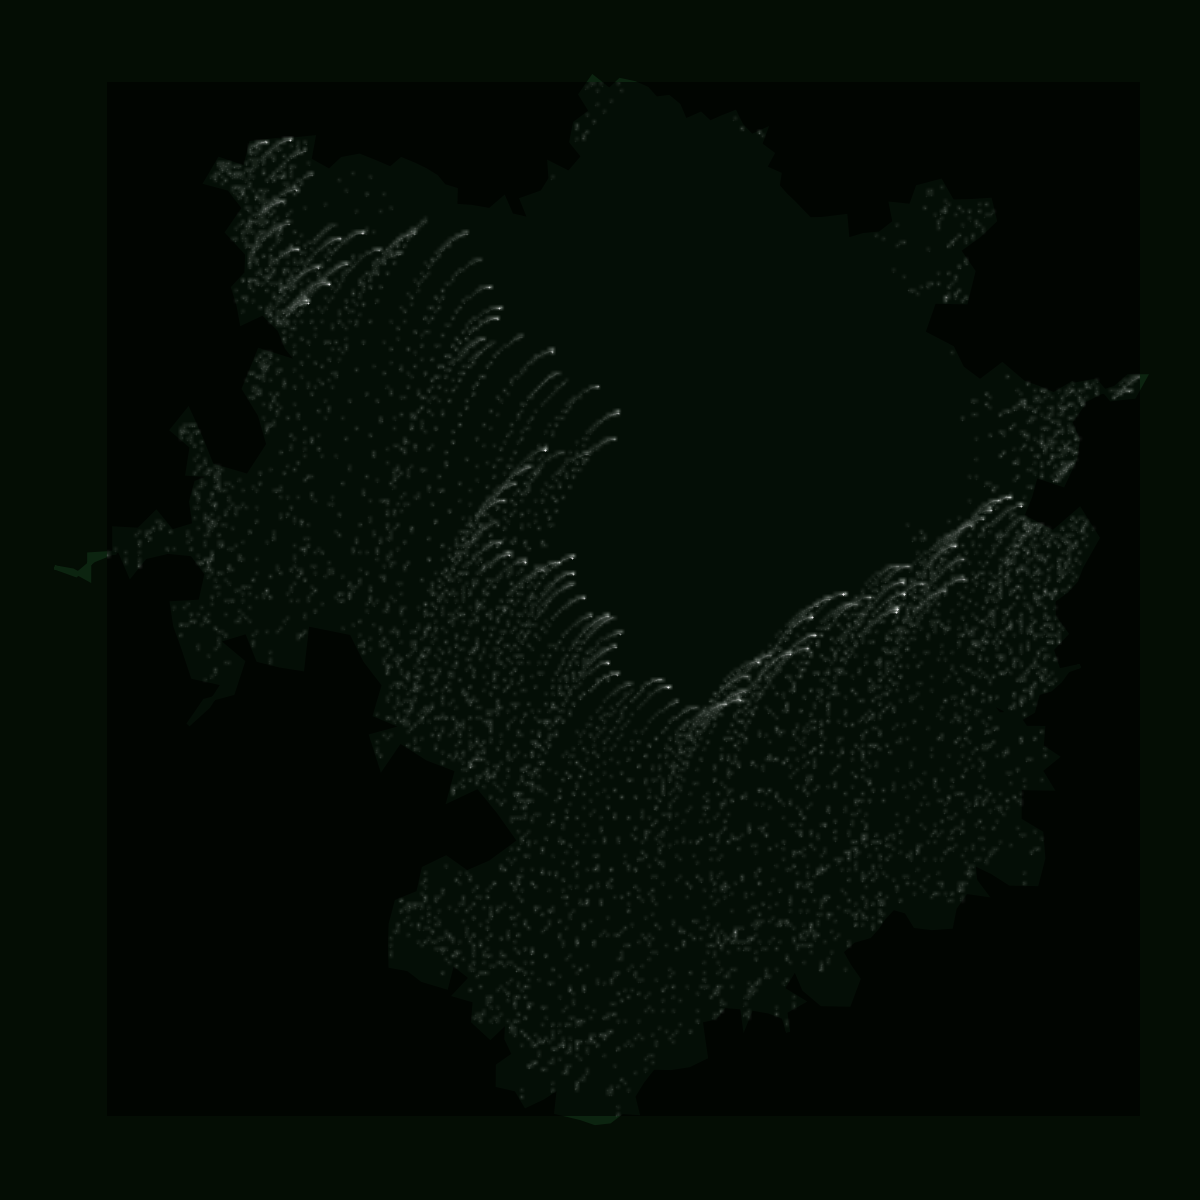

In [5]:
stdout, stderr, rc = run_frac('floresta.frac')
if rc == 0:
    print(stdout)
else:
    print(stderr or '(usando PNG pré-gerado)')
    render_csv('floresta.csv', 'floresta.png', style='forest')

show_png('floresta.png')

---
## Exemplo 3 — Montanha (`montanha.frac`)

**Modo:** coastline + decoração IFS  
**Diferença:** `roughness 0.6` (mais irregular), estilo `mountain` → paleta monocromática, terra preenchida em cinza pedra, com outline.

In [6]:
show_frac('montanha.frac')

```
fractal Montanha
    iterations 10000
    coastline
        points 5
        radius 1.0
        roughness 0.65
        depth 5
        decorate
            steps 70
            scale 0.07
            transform 0.33
                depth 4
                sierpinski
                    affine 0.33  0.5  0.0  0.0  0.5  0.0   0.0
            transform 0.33
                depth 4
                sierpinski
                    affine 0.33  0.5  0.0  0.0  0.5  0.5   0.0
            transform 0.34
                depth 4
                sierpinski
                    affine 0.34  0.5  0.0  0.0  0.5  0.25  0.5

render
    resolution 1200 1200
    style mountain

generate Montanha

```

  11,290 pontos carregados de montanha.csv
    coast: 160 pts  |  decor: 11,130 pts
  → salvo em montanha.png
Compilando: Montanha
(define Montanha (let* ((f (create-fractal Montanha)) (f (set-field f (quote iterations) 10000)) (f (set-field f (quote coastline) (list (cons (quote points) 5) (cons (quote radius) 1.0) (cons (quote roughness) 0.65) (cons (quote depth) 5) (cons (quote decorate) (list (cons (quote steps) 70) (cons (quote scale) 0.07) (cons (quote transforms) (list (transform 0.33 (with-depth 4 (ifs (create-fractal Sierpinski) (transform 0.33 (affine 0.5 0.0 0.0 0.5 0.0 0.0))))) (transform 0.33 (with-depth 4 (ifs (create-fractal Sierpinski) (transform 0.33 (affine 0.5 0.0 0.0 0.5 0.5 0.0))))) (transform 0.34 (with-depth 4 (ifs (create-fractal Sierpinski) (transform 0.34 (affine 0.5 0.0 0.0 0.5 0.25 0.5))))))))))))) f))
Configurando render: ((width . 1200) (height . 1200) (color . mono) (style . mountain))
Exportando: montanha.csv
Renderizando → montanha.png
PNG gerado.



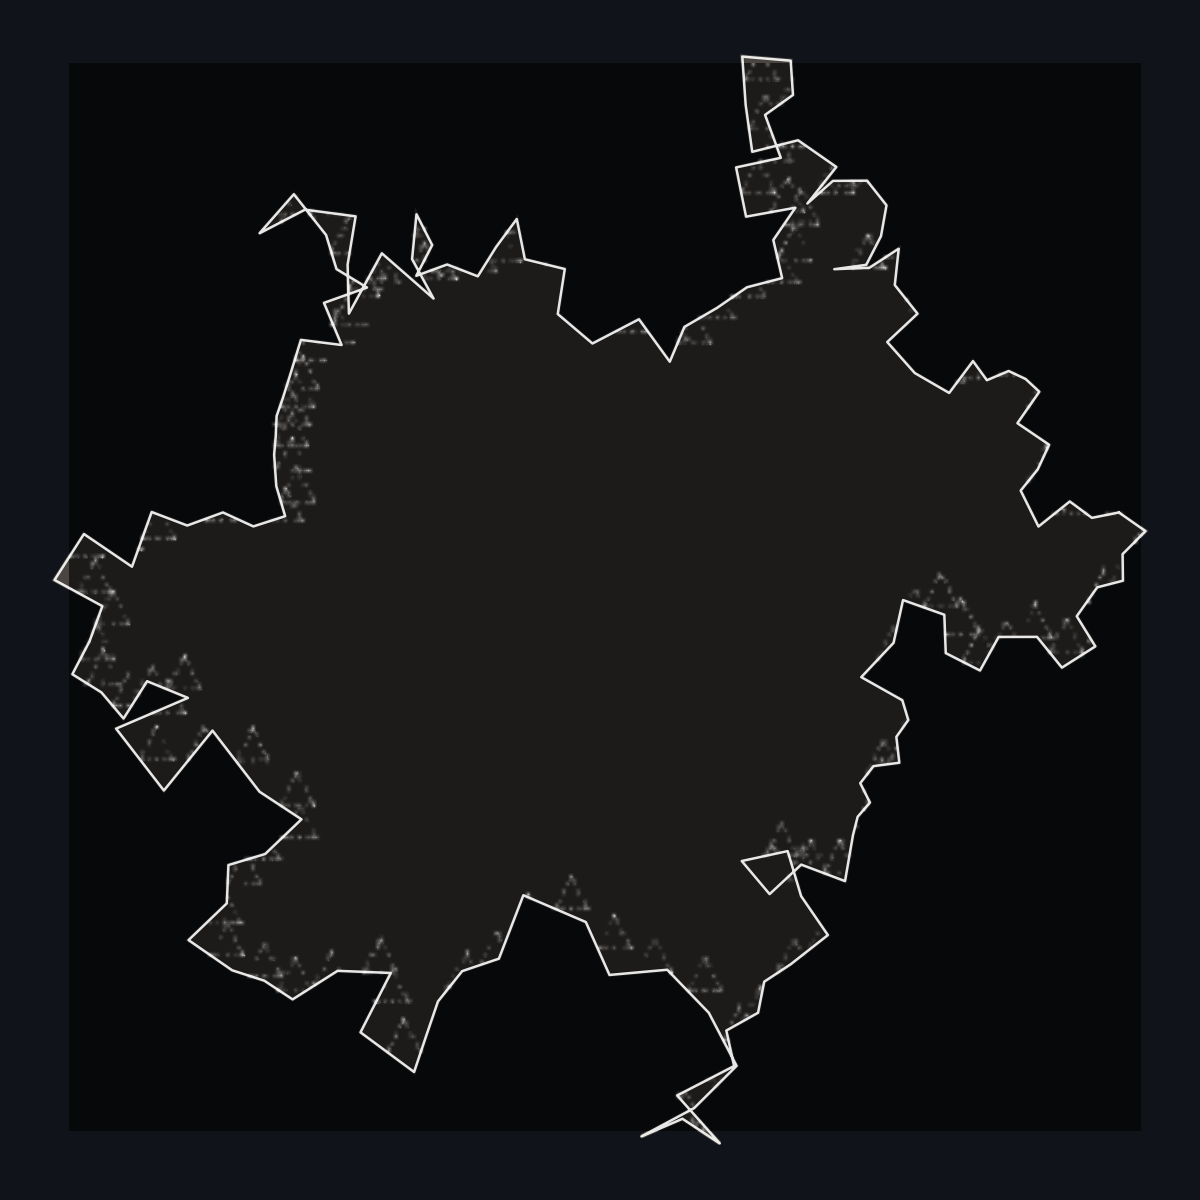

In [7]:
stdout, stderr, rc = run_frac('montanha.frac')
if rc == 0:
    print(stdout)
else:
    print(stderr or '(usando PNG pré-gerado)')
    render_csv('montanha.csv', 'montanha.png', style='mountain')

show_png('montanha.png')

---
## Exemplo 4 — England (`england.frac`)

**Modo:** coastline + decoração IFS  
**Diferença:** 12 pontos iniciais, `roughness 0.3` (menos aleatório), aproximando um contorno geográfico real.

In [8]:
show_frac('england.frac')

```
fractal England
    iterations 10000
    coastline
        points 8
        radius 1.0
        roughness 0.45
        depth 6
        decorate
            steps 90
            scale 0.055
            transform 0.85
                depth 4
                barnsley
                    affine 0.85  0.85  0.04 -0.04  0.85  0.0  1.60
            transform 0.07
                depth 4
                barnsley
                    affine 0.07  0.20 -0.26  0.23  0.22  0.0  1.60
            transform 0.07
                depth 4
                barnsley
                    affine 0.07 -0.15  0.28  0.26  0.24  0.0  0.44
            transform 0.01
                depth 4
                barnsley
                    affine 0.01  0.0   0.0   0.0   0.16  0.0  0.0

render
    resolution 1200 1200
    style island

generate England

```

  46,502 pontos carregados de england.csv
    coast: 512 pts  |  decor: 45,990 pts
  → salvo em england.png
Compilando: England
(define England (let* ((f (create-fractal England)) (f (set-field f (quote iterations) 10000)) (f (set-field f (quote coastline) (list (cons (quote points) 8) (cons (quote radius) 1.0) (cons (quote roughness) 0.45) (cons (quote depth) 6) (cons (quote decorate) (list (cons (quote steps) 90) (cons (quote scale) 0.055) (cons (quote transforms) (list (transform 0.85 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.85 (affine 0.85 0.04 -0.04 0.85 0.0 1.6))))) (transform 0.07 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.07 (affine 0.2 -0.26 0.23 0.22 0.0 1.6))))) (transform 0.07 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.07 (affine -0.15 0.28 0.26 0.24 0.0 0.44))))) (transform 0.01 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.01 (affine 0.0 0.0 0.0 0.16 0.0 0.0))))))))))))) f))
Configurando render: ((

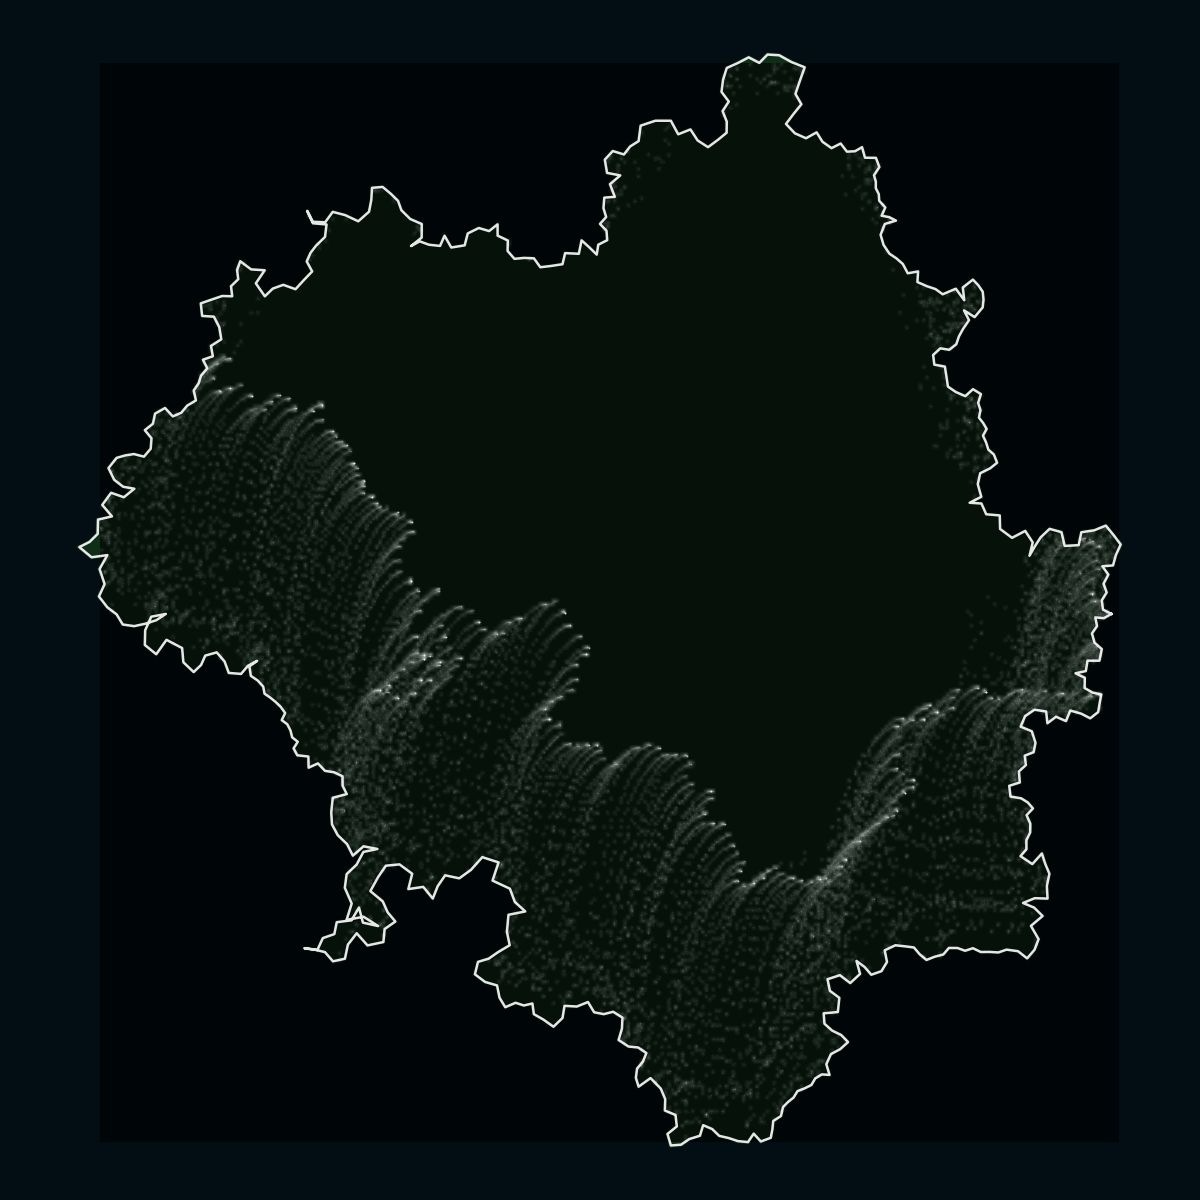

In [9]:
stdout, stderr, rc = run_frac('england.frac')
if rc == 0:
    print(stdout)
else:
    print(stderr or '(usando PNG pré-gerado)')
    render_csv('england.csv', 'england.png', style='island', color='teal')

show_png('england.png')

---
## Exemplo 5 — Sierpinski (`sierpinski.frac`)

**Modo:** IFS puro (jogo do caos)  
**Técnica:** três `transform` de peso ~1/3, cada uma com uma `affine` diferente — sem `coastline`, sem decoração, é o fractal IFS "cru".

> Nota: o parser exige um `depth` em cada `transform` que usa `sierpinski`/`barnsley` no modo IFS de nível fractal (mesmo mecanismo usado pra aninhar fractais dentro de outros via `with-depth`); `depth 1` faz cada `transform` aplicar sua própria `affine` uma vez, que é o comportamento clássico do jogo do caos.

In [ ]:
show_frac('sierpinski.frac')

In [ ]:
stdout, stderr, rc = run_frac('sierpinski.frac')
if rc == 0:
    print(stdout)
else:
    print(stderr)
show_png('sierpinski.png', width=500)

---
## Exemplo 6 — Padrões combinados (`padroes.frac`)

**Modo:** IFS puro, com `with-depth`  
**Técnica:** um `transform` sorteia entre dois padrões inteiros — metade das vezes expande 5 níveis de um Sierpinski, metade das vezes 3 níveis de um Barnsley Fern. Mesma ideia do Exemplo 4 do README ("o combinado"), só que escrito em `.frac`.

In [ ]:
show_frac('padroes.frac')

In [ ]:
stdout, stderr, rc = run_frac('padroes.frac')
if rc == 0:
    print(stdout)
else:
    print(stderr)
show_png('padroes.png', width=500)

---
## Exemplo 7 — Mandelbrot (`mandelbrot.frac`)

**Modo:** escape-time  
**Técnica:** para cada pixel `(re, im)` do plano complexo, itera `z = z² + c` até `|z| > 2` ou atingir `iterations`. A cor do pixel é proporcional ao número de iterações. Pixels que nunca escapam (conjunto de Mandelbrot) ficam pretos.

In [10]:
show_frac('mandelbrot.frac')

```
fractal Mandelbrot
    equation z=z^2+c
    iterations 150
    center -0.5 0
    zoom 100
    resolution 800 800

render
    resolution 1600 1600
    color green

generate Mandelbrot

```

  640,000 pontos carregados de mandelbrot.csv
  → salvo em mandelbrot.png
Compilando: Mandelbrot
(define Mandelbrot (let* ((f (create-fractal Mandelbrot)) (f (equation f z=z^2+c)) (f (iterations f 150)) (f (center f -0.5 0)) (f (zoom f 100)) (f (set-field f (quote resolution) (list 800 800)))) f))
Configurando render: ((width . 1600) (height . 1600) (color . green) (style . island))
Exportando: mandelbrot.csv
Renderizando → mandelbrot.png
PNG gerado.



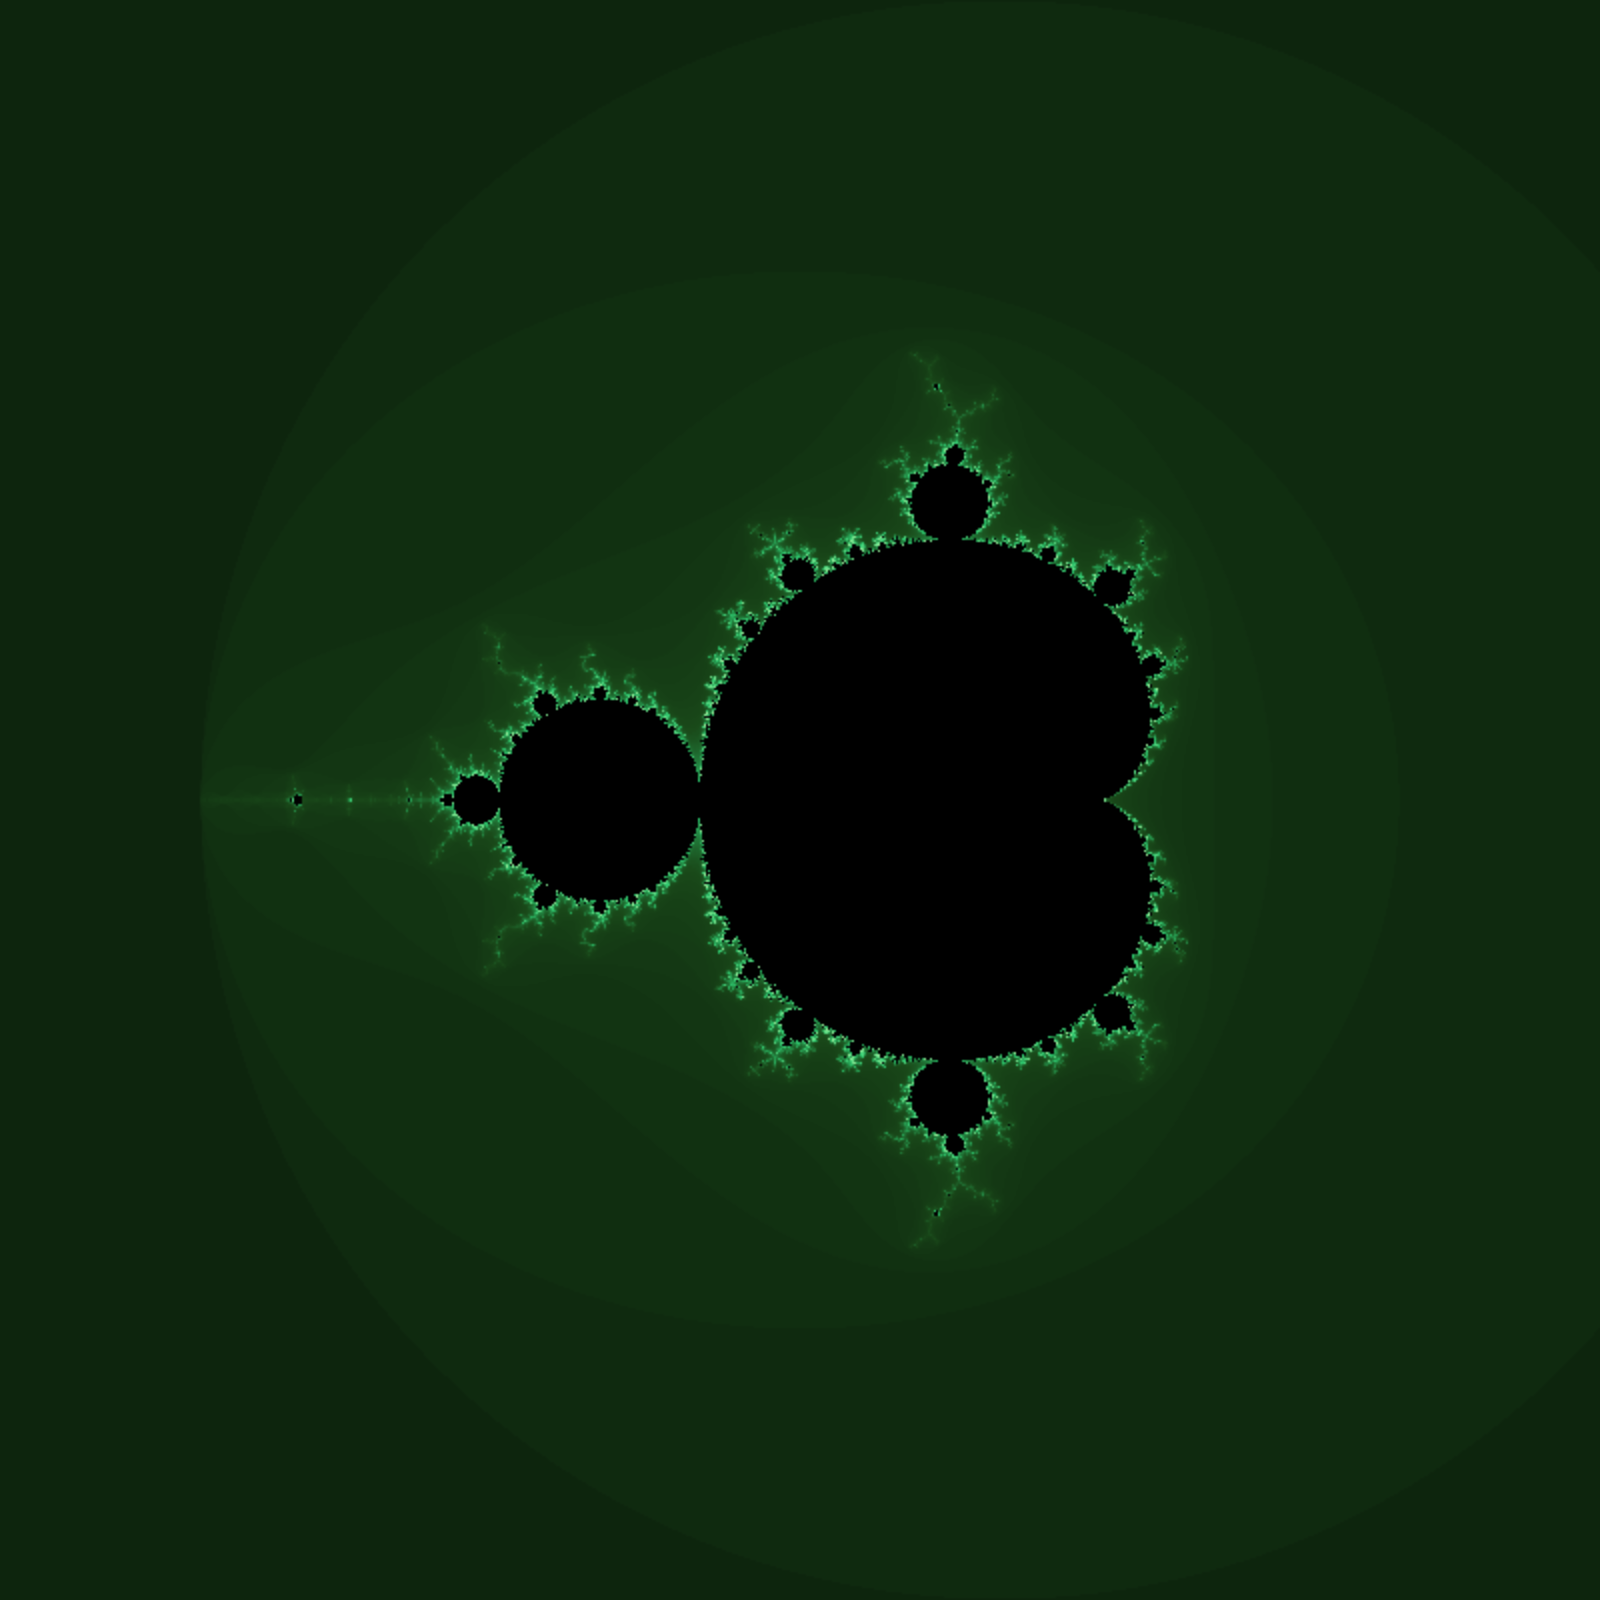

In [11]:
stdout, stderr, rc = run_frac('mandelbrot.frac')
if rc == 0:
    print(stdout)
else:
    print(stderr or '(usando PNG pré-gerado)')
    render_csv('mandelbrot.csv', 'mandelbrot.png', style='island', color='green')

show_png('mandelbrot.png')

---
## Camada Scheme — primitivas diretamente

A camada `.frac` é apenas açúcar sintático sobre as primitivas Scheme. O mesmo fractal pode ser escrito diretamente em Scheme:

```scheme
; Equivalente a ilha.frac, mas em Scheme puro:
(define ilha
  (set-field
    (set-field (create-fractal "Ilha") 'iterations 10000)
    'coastline
    (list (cons 'points 7) (cons 'radius 1.0)
          (cons 'roughness 0.4) (cons 'depth 6)
          (cons 'decorate
            (list (cons 'steps 80) (cons 'scale 0.06)
                  (cons 'transforms (list ...)))))))

(export-csv ilha "ilha.csv")
```

E com a nova função `render-png!`, a DSL pode renderizar diretamente:

```scheme
(render-png! ilha "ilha.png")
; → exporta CSV, chama python3 render_fractal.py, gera PNG
```

Pontos gerados: 15000



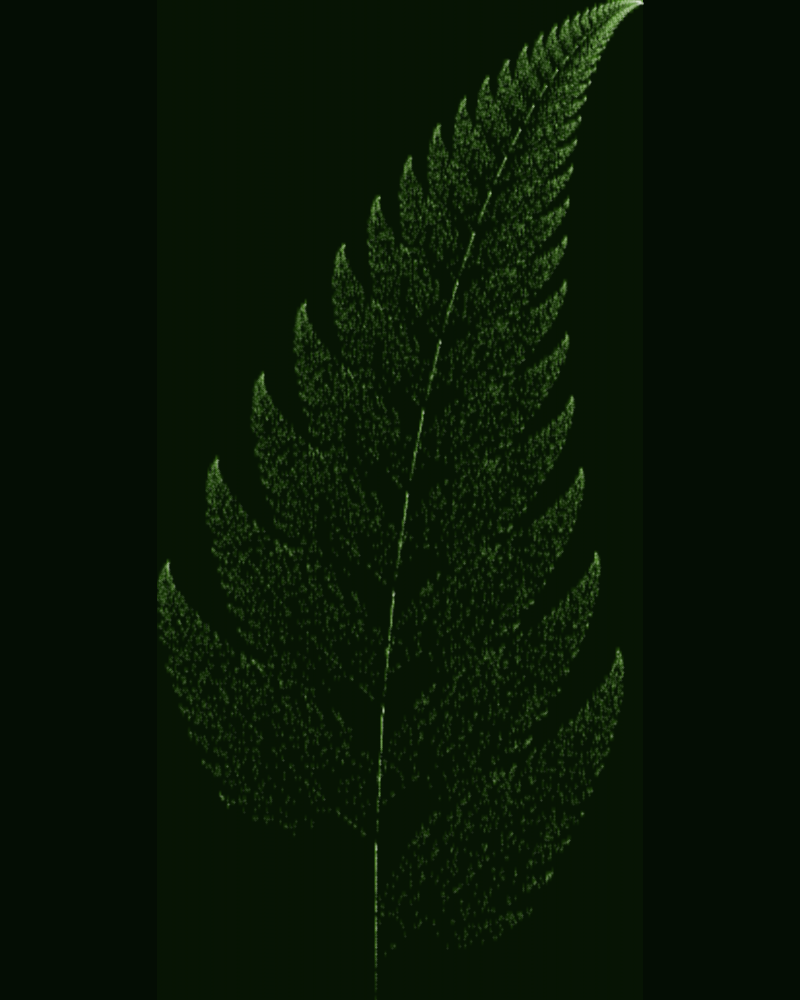

In [12]:
# Demonstração: executar Scheme diretamente (sem .frac) para gerar um Barnsley Fern
scheme_code = '''
(load "fractal-core.scm")
(load "fractal-ifs.scm")
(load "fractal-generate.scm")

(define barnsley
  (let* ((f (create-fractal "BarnsleyFern"))
         (f (set-field f 'iterations 15000))
         (f (set-field f 'ifs
              (list
                (list 'transform 0.01 (affine  0.00  0.00  0.00  0.16  0.00  0.00))
                (list 'transform 0.85 (affine  0.85  0.04 -0.04  0.85  0.00  1.60))
                (list 'transform 0.07 (affine  0.20 -0.26  0.23  0.22  0.00  1.60))
                (list 'transform 0.07 (affine -0.15  0.28  0.26  0.24  0.00  0.44))))))
    f))

(export-csv barnsley "barnsley.csv")
(display "Pontos gerados: ")
(display (length (generate barnsley)))
(newline)
'''

if HAS_GUILE:
    result = subprocess.run(
        ['guile', '--no-auto-compile', '-c', scheme_code],
        capture_output=True, text=True, cwd=str(GUILE_DIR), timeout=60
    )
    print(result.stdout or result.stderr)
    render_csv('barnsley.csv', 'barnsley.png', style='forest', color='limegreen', width=800, height=1000)
    show_png('barnsley.png', width=400)
else:
    print('Guile não disponível — exemplo teórico.')

---
## Renderização embutida na DSL

A partir da versão final, o arquivo `.frac` pode conter um bloco `render` que configura a saída. Quando `generate` é executado, a DSL chama automaticamente o renderer Python:

```
fractal Ilha
    ...

render               ← configura WIDTH/HEIGHT/COLOR/STYLE
    resolution 1200 1200
    color mono
    style island

generate Ilha        ← exporta ilha.csv E gera ilha.png automaticamente
```

No Scheme, o mesmo é feito com `render-png!`:

```scheme
; fractal-reader.scm exporta render-png!
(load "fractal-reader.scm")
(run-frac-file "../ilha.frac")   ; gera ilha.csv + ilha.png

; ou diretamente:
(render-png! meu-fractal "saida.png")
```

A função `render-png!` detecta automaticamente o caminho do renderer Python (local `../python/` ou Docker `/fractal/python/`) e lê as configurações de `render.cfg`.

---
## Parâmetros do renderer

| Parâmetro | Valores | Descrição |
|---|---|---|
| `--style` | `island`, `forest`, `mountain`, `cloud` | Estilo visual (só coastline) |
| `--color` | `green`, `ocean`, `fire`, `teal`, `limegreen`, `mono`, `gradient` | Paleta de cores |
| `--bg` | `#rrggbb` | Cor de fundo |
| `--width` / `--height` | inteiro | Dimensão do PNG em pixels |
| `--dpi` | inteiro | Resolução (padrão: 300) |
| `--alpha` | 0.0–1.0 | Transparência da nuvem de densidade |
| `--pt` | float | Tamanho do ponto no scatter |

### Modos de renderização por tipo de CSV

| `type` no CSV | Modo | Descrição |
|---|---|---|
| `coast` / `decor` | Coastline | Polígono + nuvem IFS |
| `escape` | Escape-time | Grid Mandelbrot/Julia |
| `point` | IFS legado | Heatmap de densidade |


---
## Conclusão

A FractalDSL demonstra como uma linguagem funcional com suporte a macros (Guile/Scheme) é uma plataforma natural para DSLs:

- **Homoiconicidade**: código e dados têm a mesma representação (listas), permitindo que `fractal-reader.scm` gere e `eval`ue código Scheme em tempo de execução.
- **Pipeline funcional imutável**: cada primitiva (`equation`, `iterations`, `zoom`, `ifs`, `with-depth`) é uma função pura que transforma um fractal em outro — composição sem efeitos colaterais.
- **Duas camadas**: a DSL `.frac` (externa, indentada) compila para Scheme puro, que por sua vez compila para uma alist que alimenta o engine de geração.
- **Renderização integrada**: `render-png!` fecha o loop — do `.frac` ao PNG em um único comando, sem sair do ambiente Scheme.